## PRZYKLAD

In [1]:
!pip install scikit-learn pandas seaborn matplotlib yellowbrick --quiet

In [2]:
from sklearn.datasets import make_blobs
import pandas as pd

# Generowanie danych: 200 próbek, 2 cechy, 4 centra, stałe odchylenie standardowe i random_state dla powtarzalności
dataset, classes = make_blobs(n_samples=200, n_features=2, centers=4, cluster_std=0.5, random_state=0)

# Utworzenie pandas DataFrame
df = pd.DataFrame(dataset, columns=['var1', 'var2'])
print(df.head(2))

       var1      var2
0  2.204387  1.560857
1 -1.133740  2.684673


C:\Users\Bartosz\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Nie można odnaleźć określonego pliku
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Bartosz\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\Bartosz\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Bartosz\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^

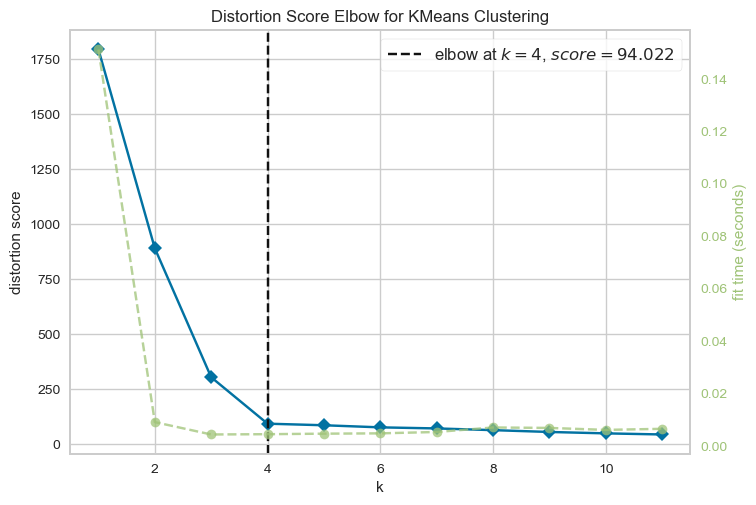

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [3]:
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

model = KMeans(random_state=0, n_init='auto') # n_init dodane by uniknąć ostrzeżeń w nowych wersjach sklearn
visualizer = KElbowVisualizer(model, k=(1,12)).fit(df)

# Zapisanie pierwszego wykresu do pliku .png
plt.savefig("wykres_1_elbow.png", dpi=300, bbox_inches="tight")
visualizer.show()

In [4]:
from sklearn.cluster import KMeans
from collections import Counter

# Inicjalizacja algorytmu i dopasowanie do danych
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=0, n_init='auto').fit(df)

# Wyświetlenie atrybutów po klastrowaniu
print("Etykiety klas:\n", kmeans.labels_)
print("\nInertia (suma kwadratów):\n", kmeans.inertia_)
print("\nLiczba iteracji:\n", kmeans.n_iter_)
print("\nCentroidy klastrów:\n", kmeans.cluster_centers_)

# Sprawdzenie rozmiaru każdego klastra
print("\nRozmiary klastrów:\n", Counter(kmeans.labels_))

Etykiety klas:
 [1 3 0 2 1 0 3 0 0 0 0 1 3 3 1 0 2 2 2 1 2 3 1 3 1 1 2 1 1 0 2 0 3 1 3 0 3
 0 0 2 2 2 2 0 1 3 0 2 2 0 2 3 3 2 0 2 3 1 0 1 2 0 1 0 2 0 1 2 3 3 1 1 0 0
 3 2 3 3 1 1 2 0 1 3 3 0 0 1 3 3 2 2 2 0 0 1 3 2 0 0 2 1 1 2 2 3 0 1 1 0 2
 3 3 1 1 0 3 3 2 0 2 3 0 1 0 3 0 3 1 0 3 1 3 2 2 3 2 2 1 2 1 3 1 1 3 1 0 1
 3 2 2 2 0 3 1 0 2 3 2 1 2 1 1 3 3 2 0 1 1 3 1 0 3 2 2 2 0 0 3 0 3 1 0 1 0
 3 3 2 0 2 1 1 0 2 3 3 3 0 2 1]

Inertia (suma kwadratów):
 94.02242630751752

Liczba iteracji:
 2

Centroidy klastrów:
 [[ 0.91932803  4.34824615]
 [ 2.06911036  0.96146833]
 [-1.33173192  7.7400479 ]
 [-1.60782913  2.9162828 ]]

Rozmiary klastrów:
 Counter({np.int32(1): 50, np.int32(3): 50, np.int32(0): 50, np.int32(2): 50})


C:\Users\Bartosz\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


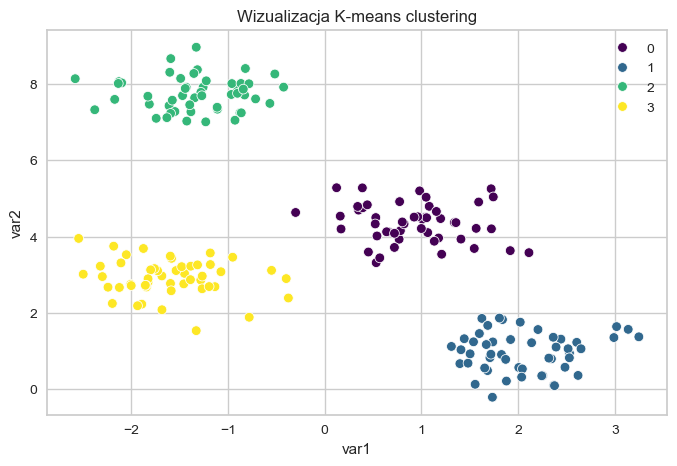

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="var1", y="var2", hue=kmeans.labels_, palette="viridis")
plt.title("Wizualizacja K-means clustering")

# Zapisanie drugiego wykresu
plt.savefig("wykres_2_klastry.png", dpi=300, bbox_inches="tight")
plt.show()

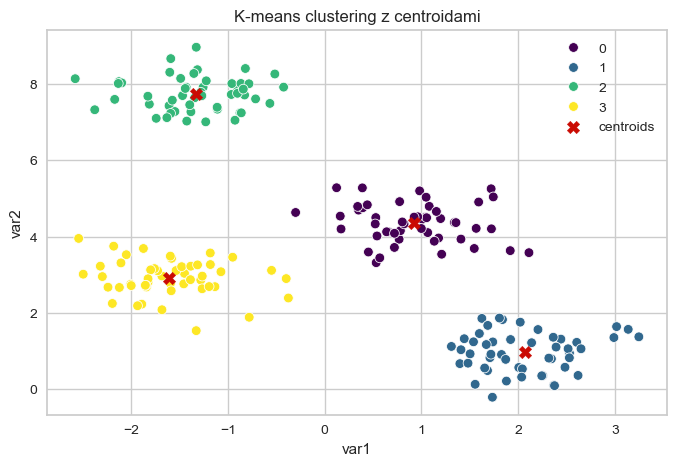

In [6]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="var1", y="var2", hue=kmeans.labels_, palette="viridis")

# Nałożenie centroidów na wykres (czerwone krzyżyki)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1],
            marker="X", c="r", s=80, label="centroids")

plt.legend()
plt.title("K-means clustering z centroidami")

# Zapisanie trzeciego wykresu
plt.savefig("wykres_3_centroidy.png", dpi=300, bbox_inches="tight")
plt.show()

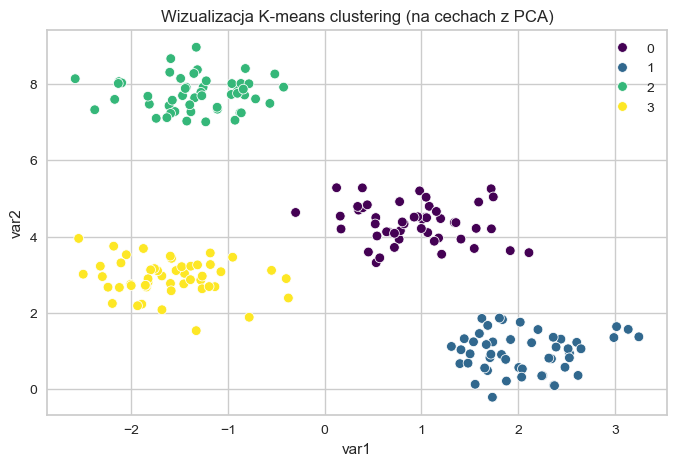

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="var1", y="var2", hue=kmeans.labels_, palette="viridis")
plt.title("Wizualizacja K-means clustering (na cechach z PCA)")

plt.show()

## LAGOON

In [9]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df_raw = pd.read_csv('VLagun_PhysChem_Years4.csv')

X = df_raw.drop(columns=['Years'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
dataset = pca.fit_transform(X_scaled)

df = pd.DataFrame(dataset, columns=['var1', 'var2'])

print(df.head(2))

       var1      var2
0 -1.318905 -1.277949
1 -3.034710  0.271312


C:\Users\Bartosz\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Bartosz\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Bartosz\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Bartosz\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak o

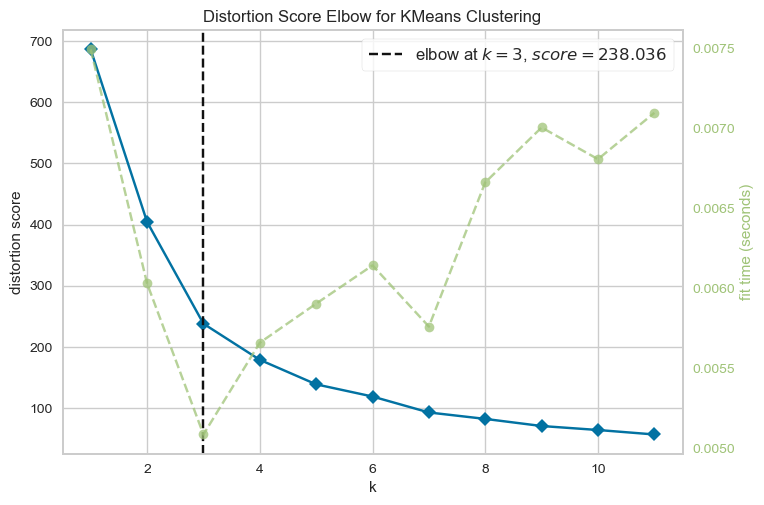

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [10]:
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

model = KMeans(random_state=0, n_init='auto')
visualizer = KElbowVisualizer(model, k=(1,12)).fit(df)

visualizer.show()

In [11]:
from sklearn.cluster import KMeans
from collections import Counter

kmeans = KMeans(n_clusters=4, init='k-means++', random_state=0, n_init='auto').fit(df)

print("Przewidziane etykiety:\n", kmeans.labels_)
print("\nInertia (Suma kwadratów wewnątrz klastrów):", kmeans.inertia_)
print("\nLiczba iteracji do konwergencji:", kmeans.n_iter_)
print("\nCentroidy klastrów:\n", kmeans.cluster_centers_)

print("\nRozmiary poszczególnych klastrów:", Counter(kmeans.labels_))

Przewidziane etykiety:
 [2 2 2 2 1 2 1 2 2 2 2 2 2 2 2 2 2 1 2 2 2 1 2 2 2 2 2 0 2 0 2 1 2 1 1 1 2
 2 2 1 2 1 1 1 1 1 1 1 1 0 0 3 3 3 3 3 3 0 0 0 0 3 3 3 0 0 0 0 0 1 3 0 0 0
 0 0 3 3 3 2 2 2 2 2 2 0 2 2 2 0 2 2 0 2 2 2 0 0 0 2 2 2 2 0 0 2 0 0 0 0 0
 0 3 0 0 3 0 0 0 3]

Inertia (Suma kwadratów wewnątrz klastrów): 178.9994753544501

Liczba iteracji do konwergencji: 4

Centroidy klastrów:
 [[ 0.84195279 -0.64816779]
 [-0.2646883   2.96936368]
 [-1.59429501 -0.48492182]
 [ 3.233287   -0.35657305]]

Rozmiary poszczególnych klastrów: Counter({np.int32(2): 49, np.int32(0): 37, np.int32(1): 18, np.int32(3): 16})


C:\Users\Bartosz\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


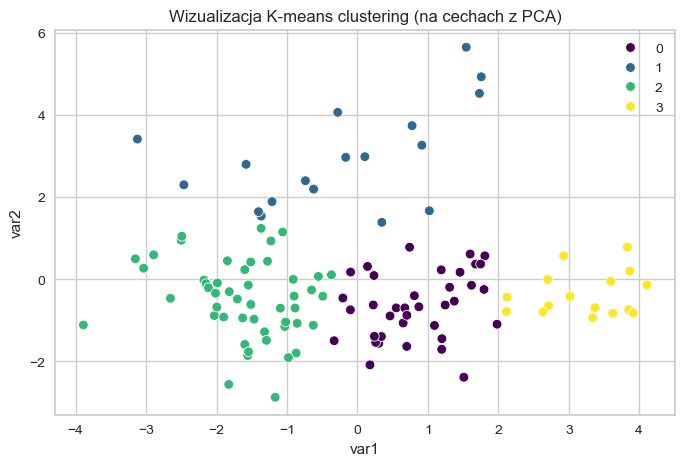

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="var1", y="var2", hue=kmeans.labels_, palette="viridis")
plt.title("Wizualizacja K-means clustering (na cechach z PCA)")

plt.show()

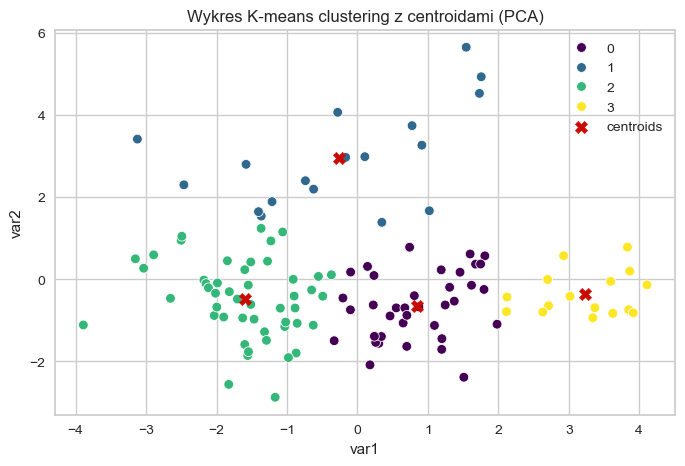

In [13]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="var1", y="var2", hue=kmeans.labels_, palette="viridis")

plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], 
            marker="X", c="r", s=80, label="centroids")

plt.legend()
plt.title("Wykres K-means clustering z centroidami (PCA)")

plt.show()